# Extracción de datos de Twitter (X)

Este cuaderno obtiene **conversaciones** sobre donación de sangre en España con la API oficial de X:

1. **Búsqueda histórica (Full Archive)** en el rango **2022–actualidad** usando `/2/tweets/search/all`.
2. De esos tuits se obtienen hasta **500** y luego se ordenan por **respuestas y likes** para quedarnos con los de más engagement.
3. **Gráfico** para ver todos (fecha, respuestas, likes) y elegir cuántos usar.
4. **Extracción de respuestas** solo de los tuits seleccionados.
5. Guardado en CSV y vista previa.

> Tu cuenta tiene acceso a **Full Archive**, así que el análisis de Twitter se basará en tuits publicados entre **2022 y hoy**.

In [6]:
import os
import time
import requests
import pandas as pd

BEARER_TOKEN = "AAAAAAAAAAAAAAAAAAAAAHiJ7AEAAAAALVTe7K2j%2BDiKwqC6xs0qPrBTcWA%3D49HVlM3W9jY9Ic9yBXC43BbYPsqZw9HS4eFbQyr46XCQPEA9x1"

headers = {"Authorization": f"Bearer {BEARER_TOKEN}"}

print("Bearer token cargado correctamente.")

Bearer token cargado correctamente.


*(Esta celda de prueba de Full Archive se ha ejecutado y ha devuelto **Status: 200**, así que tu cuenta permite búsqueda histórica 2022–actualidad. La puedes omitir en siguientes ejecuciones y usar directamente las celdas de búsqueda principal.)*

In [15]:
# (Celda de comprobación de Full Archive ya ejecutada). No es necesario volver a lanzarla salvo que cambie el plan.

Status: 200
✓ Tienes acceso a Full Archive. Se obtuvieron 10 tuits (rango 2022–ahora).
  Podemos cambiar la búsqueda principal a este endpoint y usar 2022–2026.


In [ ]:
# Búsqueda principal: Full Archive (2022–actualidad) por tramos anuales
SEARCH_URL = "https://api.twitter.com/2/tweets/search/all"

from datetime import datetime, timezone, timedelta

# Consulta: donación de sangre + motivos para NO donar (miedo, imposibilidad, barreras)
query = (
    "(\"donación de sangre\" OR \"donar sangre\" OR \"donación sangre\" "
    "OR #donarsangre OR #donacióndesangre "
    "OR \"no donar sangre\" OR \"no dono sangre\" OR \"no puedo donar\" "
    "OR \"miedo a donar\" OR \"miedo donar sangre\" OR \"no me dejan donar\" "
    "OR \"imposible donar\" OR \"no quiero donar\" OR \"barreras donación\") lang:es -is:retweet"
)

params_base = {
    "query": query,
    "max_results": 100,
    "tweet.fields": "id,text,author_id,created_at,lang,public_metrics,geo,conversation_id,referenced_tweets",
    "user.fields": "id,name,username,location,public_metrics,created_at",
    "expansions": "author_id,geo.place_id",
    "place.fields": "id,full_name,country,country_code,place_type",
}

# Tramos anuales 2022–2026 (puedes ajustar las fechas si quieres otro periodo)
YEAR_RANGES = [
    ("2022-01-01T00:00:00Z", "2023-01-01T00:00:00Z"),
    ("2023-01-01T00:00:00Z", "2024-01-01T00:00:00Z"),
    ("2024-01-01T00:00:00Z", "2025-01-01T00:00:00Z"),
    ("2025-01-01T00:00:00Z", "2026-01-01T00:00:00Z"),
    ("2026-01-01T00:00:00Z", (datetime.now(timezone.utc) - timedelta(seconds=10)).strftime("%Y-%m-%dT%H:%M:%SZ")),
]

MAX_POR_ANO = 100  # máximo de tuits por año

print("Búsqueda histórica 2022–actualidad por tramos anuales (hasta 100 tuits por año).")

def _tweet_to_row(t, users_by_id, places_by_id):
    user = users_by_id.get(t.get("author_id"), {})
    place_id = (t.get("geo") or {}).get("place_id")
    place = places_by_id.get(place_id, {}) if place_id else {}
    return {
        "tweet_id": t.get("id"),
        "created_at": t.get("created_at"),
        "text": t.get("text"),
        "lang": t.get("lang"),
        "retweet_count": (t.get("public_metrics") or {}).get("retweet_count"),
        "reply_count": (t.get("public_metrics") or {}).get("reply_count"),
        "like_count": (t.get("public_metrics") or {}).get("like_count"),
        "quote_count": (t.get("public_metrics") or {}).get("quote_count"),
        "author_id": t.get("author_id"),
        "author_username": user.get("username"),
        "author_name": user.get("name"),
        "author_location": user.get("location"),
        "place_full_name": place.get("full_name"),
        "place_country": place.get("country"),
        "place_country_code": place.get("country_code"),
        "place_type": place.get("place_type"),
        "reply_to_tweet_id": None,
    }

def search_tweets_por_ano(pause_seconds: float = 2.0):
    all_tweets = []
    for (start_time, end_time) in YEAR_RANGES:
        print(f"Buscando entre {start_time[:10]} y {end_time[:10]}...")
        params = params_base.copy()
        params["start_time"] = start_time
        params["end_time"] = end_time
        params["max_results"] = min(100, MAX_POR_ANO)

        resp = requests.get(SEARCH_URL, headers=headers, params=params)
        if resp.status_code != 200:
            print(f"  Error {resp.status_code}: {resp.text[:200]}...")
            continue

        data = resp.json()
        tweets = data.get("data", [])
        includes = data.get("includes", {})
        users_by_id = {u["id"]: u for u in includes.get("users", [])}
        places_by_id = {p["id"]: p for p in includes.get("places", [])}

        usados = 0
        for t in tweets[:MAX_POR_ANO]:
            all_tweets.append(_tweet_to_row(t, users_by_id, places_by_id))
            usados += 1
        print(f"  Año: {len(tweets)} tuits encontrados, usados {usados}. Total acumulado: {len(all_tweets)}")
        time.sleep(pause_seconds)

    return pd.DataFrame(all_tweets)

df_tweets = search_tweets_por_ano(pause_seconds=2.0)
print(f"Tuits por búsqueda (2022–actualidad, hasta {MAX_POR_ANO} por año): {len(df_tweets)}")

Búsqueda histórica 2022–actualidad por tramos anuales (hasta 100 tuits por año).
Buscando entre 2022-01-01 y 2023-01-01...
  Año: 92 tuits encontrados, usados 92. Total acumulado: 92
Buscando entre 2023-01-01 y 2024-01-01...
  Año: 93 tuits encontrados, usados 93. Total acumulado: 185
Buscando entre 2024-01-01 y 2025-01-01...
  Año: 97 tuits encontrados, usados 97. Total acumulado: 282
Buscando entre 2025-01-01 y 2026-01-01...
  Año: 100 tuits encontrados, usados 100. Total acumulado: 382
Buscando entre 2026-01-01 y 2026-03-05...
  Año: 99 tuits encontrados, usados 99. Total acumulado: 481
Tuits por búsqueda (2022–actualidad, hasta 100 por año): 481


**Estrategia por engagement:** De los tuits de búsqueda se seleccionan los que tienen **más respuestas y más likes** (conversaciones reales). Solo para esos se piden las respuestas, así ahorras recursos y obtienes hilos con más debate.

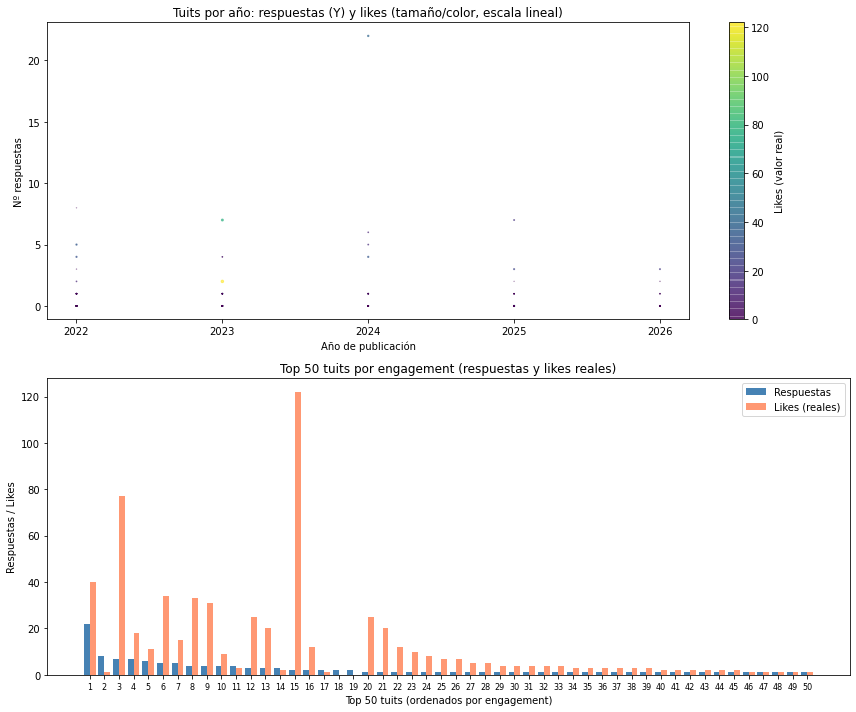

In [ ]:
import matplotlib.pyplot as plt

if len(df_tweets) > 0:
    df = df_tweets.copy()
    df["reply_count"] = pd.to_numeric(df["reply_count"], errors="coerce").fillna(0).astype(int)
    df["like_count"]  = pd.to_numeric(df["like_count"], errors="coerce").fillna(0).astype(int)
    df["created_at_dt"] = pd.to_datetime(df["created_at"], errors="coerce")
    df["year"] = df["created_at_dt"].dt.year

    # Factor para que las bolas no sean gigantes (ajusta si quieres)
    size_factor = 0.05  # subirlo = bolas más grandes; bajarlo = más pequeñas

    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    # 1) Dispersión por año: X = año, Y = respuestas, tamaño/color = likes (sin recorte)
    ax1 = axes[0]
    df_plot = df.dropna(subset=["year"])
    sizes = (df_plot["like_count"] + 1) * size_factor  # escala lineal de likes
    scatter = ax1.scatter(
        df_plot["year"],
        df_plot["reply_count"],
        s=sizes,
        alpha=0.6,
        c=df_plot["like_count"],
        cmap="viridis",
    )
    ax1.set_xticks(sorted(df_plot["year"].unique()))
    ax1.set_xlabel("Año de publicación")
    ax1.set_ylabel("Nº respuestas")
    ax1.set_title("Tuits por año: respuestas (Y) y likes (tamaño/color, escala lineal)")
    plt.colorbar(scatter, ax=ax1, label="Likes (valor real)")

    # 2) Barras: top 50 por engagement (respuestas + likes), usando likes reales
    ax2 = axes[1]
    df_eng = df.sort_values(by=["reply_count", "like_count"], ascending=[False, False]).reset_index(drop=True)
    top50 = df_eng.head(50)
    x = range(len(top50))
    ax2.bar([i - 0.2 for i in x], top50["reply_count"], width=0.4, label="Respuestas", color="steelblue")
    ax2.bar([i + 0.2 for i in x], top50["like_count"], width=0.4, label="Likes (reales)", color="coral", alpha=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(i+1) for i in x], fontsize=8)
    ax2.set_ylabel("Respuestas / Likes")
    ax2.set_xlabel("Top 50 tuits (ordenados por engagement)")
    ax2.set_title("Top 50 tuits por engagement (respuestas y likes reales)")
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

    # Dejamos df_tweets ordenado por engagement para la celda siguiente
    df_tweets = df_eng.drop(columns=["created_at_dt", "year"], errors="ignore")

In [21]:
# Resumen de respuestas y likes para los TOP 50
total_replies_top50 = df_tweets["reply_count"].sum()
total_likes_top50 = df_tweets["like_count"].sum()

print(f"Número de tuits TOP: {len(df_tweets)}")
print(f"Respuestas totales (reply_count) en los TOP {len(df_tweets)}: {total_replies_top50}")
print(f"Likes totales (like_count) en los TOP {len(df_tweets)}: {total_likes_top50}")
print("\nEstadísticos de respuestas en TOP:")
print(df_tweets["reply_count"].describe())
print("\nEstadísticos de likes en TOP:")
print(df_tweets["like_count"].describe())

Número de tuits TOP: 481
Respuestas totales (reply_count) en los TOP 481: 160
Likes totales (like_count) en los TOP 481: 1178

Estadísticos de respuestas en TOP:
count    481.000000
mean       0.332640
std        1.334461
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       22.000000
Name: reply_count, dtype: float64

Estadísticos de likes en TOP:
count    481.000000
mean       2.449064
std        8.097454
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max      122.000000
Name: like_count, dtype: float64


In [24]:
# Tras ver el gráfico anterior: quedarnos solo con los TOP tuits para extraer respuestas
TOP_TWEETS_POR_ENGAGEMENT = 30   # Ajusta según lo que quieras (en el gráfico ves el top 50)

if len(df_tweets) > 0:
    df_top = df_tweets.head(TOP_TWEETS_POR_ENGAGEMENT).copy()
    print(f"Seleccionados los {len(df_top)} tuits con más engagement (respuestas + likes).")
    print(f"Ejemplo: reply_count máx = {df_top['reply_count'].max()}, like_count máx = {df_top['like_count'].max()}.")
    df_tweets = df_top

Seleccionados los 30 tuits con más engagement (respuestas + likes).
Ejemplo: reply_count máx = 22, like_count máx = 122.


**Respuestas:** Se obtienen las respuestas **solo de los tuits con más engagement** (los seleccionados arriba). Cada respuesta consume 1 recurso. Puedes ajustar `REPLIES_PER_TWEET` (máx. respuestas por tuit).

In [ ]:
# Obtener respuestas (comentarios) de cada tuit de búsqueda. 1 respuesta = 1 recurso.
REPLIES_PER_TWEET = 22  # máx. respuestas por tuit (ajusta según créditos: 100 tuits + 100*15 = 1600 recursos)

def fetch_replies_for_tweets(df_root, max_replies_per_tweet=10, pause_seconds=1.5):
    if len(df_root) == 0:
        return df_root
    reply_params_base = {
        "max_results": min(100, max_replies_per_tweet),
        "tweet.fields": "id,text,author_id,created_at,lang,public_metrics,conversation_id,referenced_tweets",
        "user.fields": "id,name,username,location",
        "expansions": "author_id",
    }
    all_replies = []
    for i, row in df_root.iterrows():
        tid = row["tweet_id"]
        q = f"conversation_id:{tid} -is:retweet"
        resp = requests.get(SEARCH_URL, headers=headers, params={"query": q, **reply_params_base})
        if resp.status_code == 402:
            print("Error 402 al obtener respuestas. Se guardan solo los tuits de búsqueda.")
            break
        if resp.status_code != 200:
            continue
        data = resp.json()
        tweets = data.get("data", [])
        includes = data.get("includes", {})
        users_by_id = {u["id"]: u for u in includes.get("users", [])}
        places_by_id = {}
        for t in tweets:
            r = _tweet_to_row(t, users_by_id, places_by_id)
            r["reply_to_tweet_id"] = tid
            all_replies.append(r)
        if (i + 1) % 20 == 0:
            print(f"  Respuestas obtenidas para {i+1}/{len(df_root)} tuits. Total respuestas: {len(all_replies)}")
        time.sleep(pause_seconds)
    if all_replies:
        df_root["reply_to_tweet_id"] = None
        return pd.concat([df_root, pd.DataFrame(all_replies)], ignore_index=True)
    return df_root

if len(df_tweets) > 0:
    print("Obteniendo respuestas (conversación)...")
    df_tweets = fetch_replies_for_tweets(df_tweets, max_replies_per_tweet=REPLIES_PER_TWEET, pause_seconds=1.5)
    print(f"Total (tuits + respuestas): {len(df_tweets)}")

Obteniendo respuestas (conversación)...
  Respuestas obtenidas para 20/30 tuits. Total respuestas: 8
Total (tuits + respuestas): 38


In [ ]:
output_path = "twitter_donacion_sangre_es_2022-2026.csv"
if len(df_tweets) > 0:
    df_tweets.to_csv(output_path, index=False)
    print(f"Guardado {len(df_tweets)} tuits en {output_path}\n")
    print("Vista previa (primeras filas):")
    display(df_tweets.head())
else:
    print("No se obtuvo ningún tuit.")


Guardado 38 tuits en twitter_donacion_sangre_es_2022-2026.csv

Vista previa (primeras filas):


,tweet_id,created_at,text,lang,retweet_count,reply_count,like_count,quote_count,author_id,author_username,author_name,author_location,place_full_name,place_country,place_country_code,place_type,reply_to_tweet_id
0,1874097166295458003,2024-12-31T14:15:58.000Z,"Salvar vidas está en tus manos. Junto a @HemocentroDO, te invitamos a donar sangre y a ser parte de la solución que nuestro país necesita. 🌟❤️ #DonaSangre #DonaVida https://t.co/kTZBMqbryj",es,15,22,40,0,203664009,SuperateRDO,Supérate,República Dominicana,None,None,None,None,None
1,1608924204401057792,2022-12-30T20:33:17.000Z,"@gadarovi Pero yo estoy hablando específicamente del tema aquel que escribí ""Testigos de Jehová vs donación de sangre"" en el tema aquel q Ud dice, entonces ellos deben de tener una placa guinda en...",es,0,8,1,0,1364518542,eacp507,Edwin Abdiel,"Los Santos, Panamá",None,None,None,None,None
2,1741244551824630219,2023-12-30T23:47:06.000Z,❤¡Donar sangre es salvar vidas! \n\n#CDRCuba #Cuba #EstaEsLaRevolución https://t.co/McAQLDKpVS,es,111,7,77,3,1222172279381118976,cdr_cuba,CDR de Cuba,La Habana,None,None,None,None,None
3,2006497915934556577,2025-12-31T22:49:16.000Z,Compañeras de la #ZonaViñaDelMar y alrededores participaron de la campaña de recolección de dadores de Sangre junto a los Bomberos de Viña del Mar y el Centro de Sangre Valparaíso. \n#JuntosSalva...,es,3,7,18,0,193493377,CHICASDECALIPSO,Fans Club Chicas de Calipso 🇨🇱,chile /9951118086 22/7723034,None,None,None,None,None
4,1873848482337087988,2024-12-30T21:47:47.000Z,"Si es necesario donar sangre pienso que será o Marta o Jesús.\nQuiero pensar que en algún momento se va a descubrir que Andrés no es un de La Reina,es adoptado por eso es así😏🤪\n#mafin https://t.c...",es,1,6,11,0,1823032476190625792,CrisMafinBoom,Cris🧁💥,None,None,None,None,None,None


: 